/tmp/ipython-input-1787829820.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.05, 0, 1, 1])


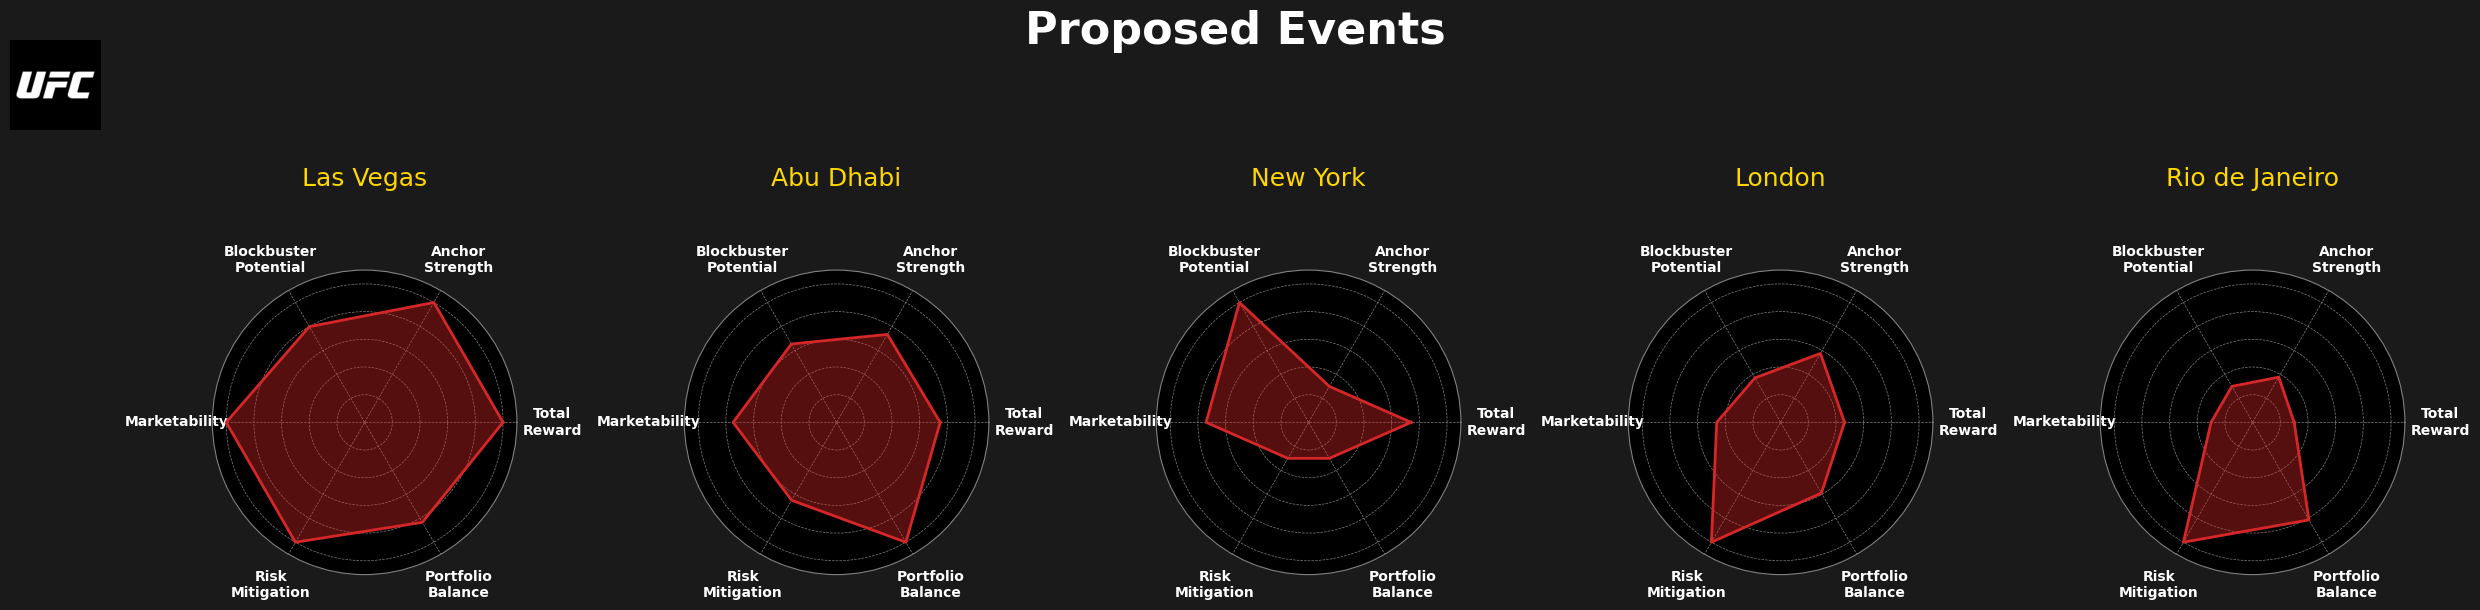

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
from PIL import Image

# --- 1. Recreate and Structure Data from your file ---
# Data is embedded to ensure the script is self-contained and runs without errors.
data = {
    'Fighter A': [
        'Dustin Poirier 🇺🇸', 'Islam Makhachev 🇷🇺', 'Jon Jones 🇺🇸', 'Tom Aspinall 🇬🇧',
        'Deiveson Figueiredo 🇧🇷', 'Justin Gaethje 🇺🇸', 'Khamzat Chimaev 🇸🇪 (Chechen)',
        'Colby Covington 🇺🇸', 'Leon Edwards 🇬🇧', 'Amanda Nunes 🇧🇷'
    ],
    'Fighter B': [
        'Arman Tsarukyan 🇦🇲', 'Beneil Dariush 🇺🇸', 'Sergei Pavlovich 🇷🇺', 'Curtis Blaydes 🇺🇸',
        'Petr Yan 🇷🇺', 'Rafael Fiziev 🇰🇬', 'Sean Strickland 🇺🇸', 'Shavkat Rakhmonov 🇰🇿',
        'Belal Muhammad 🇵🇸', 'Irene Aldana 🇲🇽'
    ],
    'Combined Pop Score': [192.7, 186.5, 190.3, 182.8, 178.2, 184.6, 180.5, 176.4, 172.5, 170.5]
}
df = pd.DataFrame(data)

# --- Process Data ---
df['PPV Sales (Expected)'] = (df['Combined Pop Score'] * 4000).astype(int)

# --- Manually and Explicitly Assign Roles and Locations ---
event_structure = {
    'Jon Jones 🇺🇸': {'Role': 'Blockbuster', 'Location': 'New York', 'Risk Tier': 'High'},
    'Colby Covington 🇺🇸': {'Role': 'Anchor', 'Location': 'New York', 'Risk Tier': 'Medium'},
    'Khamzat Chimaev 🇸🇪 (Chechen)': {'Role': 'Blockbuster', 'Location': 'Abu Dhabi', 'Risk Tier': 'High'},
    'Islam Makhachev 🇷🇺': {'Role': 'Anchor', 'Location': 'Abu Dhabi', 'Risk Tier': 'Low'},
    'Justin Gaethje 🇺🇸': {'Role': 'Blockbuster', 'Location': 'Las Vegas', 'Risk Tier': 'Medium'},
    'Dustin Poirier 🇺🇸': {'Role': 'Anchor', 'Location': 'Las Vegas', 'Risk Tier': 'Low'},
    'Leon Edwards 🇬🇧': {'Role': 'Blockbuster', 'Location': 'London', 'Risk Tier': 'Medium'},
    'Tom Aspinall 🇬🇧': {'Role': 'Anchor', 'Location': 'London', 'Risk Tier': 'Low'},
    'Amanda Nunes 🇧🇷': {'Role': 'Blockbuster', 'Location': 'Rio de Janeiro', 'Risk Tier': 'Medium'},
    'Deiveson Figueiredo 🇧🇷': {'Role': 'Anchor', 'Location': 'Rio de Janeiro', 'Risk Tier': 'Low'}
}
df['Role'] = df['Fighter A'].map(lambda fa: event_structure[fa]['Role'])
df['Location'] = df['Fighter A'].map(lambda fa: event_structure[fa]['Location'])
df['Risk Tier'] = df['Fighter A'].map(lambda fa: event_structure[fa]['Risk Tier'])

risk_map_numeric = {'Low': 1, 'Medium': 2, 'High': 3}
df['Risk_Num'] = df['Risk Tier'].map(risk_map_numeric)


# --- Aggregate Data and Calculate Hexagon Metrics ---
agg_data = []
for loc in df['Location'].unique():
    loc_df = df[df['Location'] == loc].copy()
    anchor = loc_df[loc_df['Role'] == 'Anchor'].iloc[0]
    blockbuster = loc_df[loc_df['Role'] == 'Blockbuster'].iloc[0]

    total_ppv = anchor['PPV Sales (Expected)'] + blockbuster['PPV Sales (Expected)']
    balance = 100 - (abs(anchor['PPV Sales (Expected)'] - blockbuster['PPV Sales (Expected)']) / total_ppv * 100)

    agg_data.append({
        'Location': loc,
        'Total Reward': total_ppv,
        'Anchor Strength': anchor['PPV Sales (Expected)'],
        'Blockbuster Potential': blockbuster['PPV Sales (Expected)'],
        'Marketability': loc_df['Combined Pop Score'].mean(),
        'Risk Mitigation': 3.5 - loc_df['Risk_Num'].mean(), # Inverse of risk (higher is better)
        'Portfolio Balance': balance
    })
agg_df = pd.DataFrame(agg_data)

# --- Corrected Normalization for Better Visual Balance ---
metrics = ['Total Reward', 'Anchor Strength', 'Blockbuster Potential', 'Marketability', 'Risk Mitigation', 'Portfolio Balance']
normalized_df = agg_df.copy()
for metric in metrics:
    min_val = agg_df[metric].min()
    max_val = agg_df[metric].max()
    # This improved formula sets a "floor" for the values, preventing any one chart from looking too small.
    normalized_df[metric] = 30 + 70 * (agg_df[metric] - min_val) / (max_val - min_val) if (max_val - min_val) != 0 else 50


# --- 2. Create the Hexagon Dashboard ---
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
fig.set_facecolor('#1a1a1a')
fig.suptitle('Proposed Events', fontsize=32, fontweight='bold', color='white', y=1.1)

# --- Plotting setup ---
angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1] # complete the loop

for ax, (i, row) in zip(axes, normalized_df.iterrows()):
    values = row[metrics].tolist()
    values += values[:1] # complete the loop

    # --- Plotting ---
    ax.plot(angles, values, color='#d62728', linewidth=2, linestyle='solid', zorder=3)
    ax.fill(angles, values, color='#d62728', alpha=0.4, zorder=2)

    # --- Formatting ---
    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m.replace(' ', '\n') for m in metrics], color='white', size=10, fontweight='bold')
    ax.tick_params(pad=15)
    ax.set_ylim(0, 110) # Set a consistent limit

    # Set the title for each hexagon
    ax.set_title(row['Location'], size=18, color='#FFD700', y=1.25)

    # Customize the grid lines
    ax.grid(color='grey', linestyle='--', linewidth=0.5)
    ax.spines['polar'].set_color('grey')

# --- Add UFC Logo ---
try:
    # Load the image from the file path provided by the user
    img = Image.open('/content/UFC logo.png').convert("RGBA")

    logo_ax = fig.add_axes([0.01, 0.9, 0.08, 0.15], anchor='NW', zorder=10)
    logo_ax.imshow(img)
    logo_ax.axis('off')
except Exception as e:
    print(f"Could not load UFC logo: {e}")

plt.tight_layout(rect=[0.05, 0, 1, 1])
plt.show()

# To save the chart to a file
# plt.savefig('UFC_Power_Hexagon_Corrected.png', dpi=300, facecolor='#1a1a1a', bbox_inches='tight')